In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")
print("FastF1 version:", fastf1.__version__)

Libraries imported successfully!
FastF1 version: 3.8.3


In [2]:
# ============================================================
# ENABLE FASTF1 CACHE
# ============================================================

fastf1.Cache.enable_cache("../cache")

print("FastF1 cache enabled successfully!")

FastF1 cache enabled successfully!


In [3]:
# ============================================================
# LOAD 2026 F1 SEASON SCHEDULE
# ============================================================

schedule = fastf1.get_event_schedule(2026)

print("========== 2026 F1 EVENT SCHEDULE ==========")

print(
    schedule[
        [
            "RoundNumber",
            "EventName",
            "EventDate"
        ]
    ].to_string(index=False)
)

========== 2026 F1 EVENT SCHEDULE ==========
 RoundNumber                EventName  EventDate
           0       Pre-Season Testing 2026-02-13
           0       Pre-Season Testing 2026-02-20
           1    Australian Grand Prix 2026-03-08
           2       Chinese Grand Prix 2026-03-15
           3      Japanese Grand Prix 2026-03-29
           4         Miami Grand Prix 2026-05-03
           5      Canadian Grand Prix 2026-05-24
           6        Monaco Grand Prix 2026-06-07
           7     Barcelona Grand Prix 2026-06-14
           8      Austrian Grand Prix 2026-06-28
           9       British Grand Prix 2026-07-05
          10       Belgian Grand Prix 2026-07-19
          11     Hungarian Grand Prix 2026-07-26
          12         Dutch Grand Prix 2026-08-23
          13       Italian Grand Prix 2026-09-06
          14       Spanish Grand Prix 2026-09-13
          15    Azerbaijan Grand Prix 2026-09-26
          16       Bahrain Grand Prix 2026-10-04
          17     Singapo

In [4]:
# ============================================================
# AUSTRALIAN GRAND PRIX
# ============================================================

australia_event = schedule[
    schedule["EventName"].str.contains(
        "Australian",
        case=False,
        na=False
    )
]

print("========== AUSTRALIAN GRAND PRIX ==========")

print(
    australia_event.to_string(index=False)
)

========== AUSTRALIAN GRAND PRIX ==========
 RoundNumber   Country  Location                                  OfficialEventName  EventDate             EventName  EventFormat   Session1              Session1Date     Session1DateUtc   Session2              Session2Date     Session2DateUtc   Session3              Session3Date     Session3DateUtc   Session4              Session4Date     Session4DateUtc Session5              Session5Date     Session5DateUtc  F1ApiSupport
           1 Australia Melbourne FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX 2026 2026-03-08 Australian Grand Prix conventional Practice 1 2026-03-06 12:30:00+11:00 2026-03-06 01:30:00 Practice 2 2026-03-06 16:00:00+11:00 2026-03-06 05:00:00 Practice 3 2026-03-07 12:30:00+11:00 2026-03-07 01:30:00 Qualifying 2026-03-07 16:00:00+11:00 2026-03-07 05:00:00     Race 2026-03-08 15:00:00+11:00 2026-03-08 04:00:00          True


In [5]:
# ============================================================
# LOAD AUSTRALIAN GP QUALIFYING
# ============================================================

print("Loading Australian GP Qualifying...")

qualifying = fastf1.get_session(
    2026,
    "Australia",
    "Q"
)

qualifying.load(
    telemetry=False,
    laps=True,
    weather=False,
    messages=False
)

print("\nQualifying session loaded successfully!")

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loading Australian GP Qualifying...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']



Qualifying session loaded successfully!


In [6]:
# ============================================================
# SESSION INFORMATION
# ============================================================

print("========== SESSION INFORMATION ==========")

print("Event:")
print(qualifying.event)

print("\nSession Name:")
print(qualifying.name)

print("\nSession Date:")
print(qualifying.date)

========== SESSION INFORMATION ==========
Event:
RoundNumber                                                          1
Country                                                      Australia
Location                                                     Melbourne
OfficialEventName    FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...
EventDate                                          2026-03-08 00:00:00
EventName                                        Australian Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2026-03-06 12:30:00+11:00
Session1DateUtc                                    2026-03-06 01:30:00
Session2                                                    Practice 2
Session2Date                                 2026-03-06 16:00:00+11:00
Session2DateUtc                                    2026-03-06 05:00:00
Session3                    

In [7]:
# ============================================================
# DRIVER RESULTS
# ============================================================

print("========== DRIVER RESULTS ==========")

results = qualifying.results[
    [
        "Abbreviation",
        "FullName",
        "TeamName",
        "Position",
        "Q1",
        "Q2",
        "Q3"
    ]
]

print(
    results.to_string(index=False)
)

========== DRIVER RESULTS ==========
Abbreviation          FullName        TeamName  Position                     Q1                     Q2                     Q3
         RUS    George Russell        Mercedes       1.0 0 days 00:01:19.507000 0 days 00:01:18.934000 0 days 00:01:18.518000
         ANT    Kimi Antonelli        Mercedes       2.0 0 days 00:01:20.120000 0 days 00:01:19.435000 0 days 00:01:18.811000
         HAD      Isack Hadjar Red Bull Racing       3.0 0 days 00:01:20.023000 0 days 00:01:19.653000 0 days 00:01:19.303000
         LEC   Charles Leclerc         Ferrari       4.0 0 days 00:01:20.226000 0 days 00:01:19.357000 0 days 00:01:19.327000
         PIA     Oscar Piastri         McLaren       5.0 0 days 00:01:19.664000 0 days 00:01:19.525000 0 days 00:01:19.380000
         NOR      Lando Norris         McLaren       6.0 0 days 00:01:20.010000 0 days 00:01:19.882000 0 days 00:01:19.475000
         HAM    Lewis Hamilton         Ferrari       7.0 0 days 00:01:19.811000 0

In [8]:
# ============================================================
# LAP DATA INFORMATION
# ============================================================

laps = qualifying.laps

print("========== LAP DATA INFORMATION ==========")

print(
    "Number of rows:",
    len(laps)
)

print(
    "Number of columns:",
    len(laps.columns)
)

print("\nColumns:")

print(
    laps.columns.tolist()
)

========== LAP DATA INFORMATION ==========
Number of rows: 353
Number of columns: 31

Columns:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [9]:
# ============================================================
# FIRST FIVE LAP RECORDS
# ============================================================

print("========== FIRST FIVE LAP RECORDS ==========")

print(
    laps.head()
)

========== FIRST FIVE LAP RECORDS ==========
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:18:17.451000    RUS           63 0 days 00:01:51.876000   
1 0 days 00:19:37.291000    RUS           63 0 days 00:01:19.840000   
2 0 days 00:21:38.860000    RUS           63 0 days 00:02:01.569000   
3 0 days 00:32:02.050000    RUS           63                    NaT   
4 0 days 00:33:52.363000    RUS           63 0 days 00:01:50.313000   

   LapNumber  Stint             PitOutTime              PitInTime  \
0        1.0    1.0 0 days 00:16:28.955000                    NaT   
1        2.0    1.0                    NaT                    NaT   
2        3.0    1.0                    NaT 0 days 00:21:24.695000   
3        4.0    2.0 0 days 00:21:42.023000 0 days 00:23:38.517000   
4        5.0    3.0 0 days 00:32:12.182000                    NaT   

             Sector1Time            Sector2Time  ... FreshTyre      Team  \
0 0 days 00:00:41.997000 0 days 00:00

In [10]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_values = (
    laps.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

print("========== MISSING VALUES ==========")

print(missing_values)

========== MISSING VALUES ==========
LapStartDate          353
Deleted               353
Position              353
PitInTime             260
PitOutTime            254
LapTime               107
SpeedFL                93
Sector3Time            90
Sector3SessionTime     90
Sector1Time            19
Sector1SessionTime     19
Sector2SessionTime     12
Sector2Time            12
SpeedI2                12
SpeedI1                 6
SpeedST                 1
DriverNumber            0
LapNumber               0
Time                    0
Stint                   0
Driver                  0
Compound                0
IsPersonalBest          0
Team                    0
FreshTyre               0
TyreLife                0
LapStartTime            0
TrackStatus             0
DeletedReason           0
FastF1Generated         0
IsAccurate              0
dtype: int64


In [11]:
# ============================================================
# DRIVER PARTICIPATION
# ============================================================

driver_counts = (
    laps["Driver"]
    .value_counts()
)

print("========== LAP COUNTS BY DRIVER ==========")

print(driver_counts)

========== LAP COUNTS BY DRIVER ==========
Driver
NOR    25
PIA    25
LIN    24
HAM    24
LAW    23
LEC    23
RUS    22
HAD    19
ALB    19
ANT    18
BEA    18
HUL    18
GAS    18
OCO    18
COL    18
BOR    14
ALO    10
BOT     8
PER     7
VER     2
Name: count, dtype: int64


In [12]:
# ============================================================
# LAP TIME STATISTICS
# ============================================================

lap_time_stats = (
    laps["LapTime"]
    .dropna()
    .dt.total_seconds()
    .describe()
)

print("========== LAP TIME STATISTICS ==========")

print(
    lap_time_stats
)

========== LAP TIME STATISTICS ==========
count    246.000000
mean      97.348154
std       16.582526
min       78.518000
25%       80.856000
50%       96.118500
75%      109.943750
max      149.731000
Name: LapTime, dtype: float64


In [13]:
# ============================================================
# FASTEST QUALIFYING LAP
# ============================================================

valid_laps = laps[
    laps["LapTime"].notna()
].copy()

valid_laps["LapTimeSeconds"] = (
    valid_laps["LapTime"]
    .dt.total_seconds()
)

fastest_lap = valid_laps.loc[
    valid_laps["LapTimeSeconds"].idxmin()
]

print("========== FASTEST QUALIFYING LAP ==========")

print(
    fastest_lap[
        [
            "Driver",
            "LapNumber",
            "LapTime",
            "Compound",
            "Team"
        ]
    ]
)

========== FASTEST QUALIFYING LAP ==========
Driver                          RUS
LapNumber                      21.0
LapTime      0 days 00:01:18.518000
Compound                       SOFT
Team                       Mercedes
dtype: object


In [14]:
# ============================================================
# FASTEST LAP BY DRIVER
# ============================================================

fastest_by_driver = (
    valid_laps
    .loc[
        valid_laps
        .groupby("Driver")["LapTimeSeconds"]
        .idxmin()
    ]
    [
        [
            "Driver",
            "LapNumber",
            "LapTime",
            "Compound",
            "Team"
        ]
    ]
    .sort_values("LapTime")
)

print("========== FASTEST LAP BY DRIVER ==========")

print(
    fastest_by_driver.to_string(
        index=False
    )
)

========== FASTEST LAP BY DRIVER ==========
Driver  LapNumber                LapTime Compound            Team
   RUS       21.0 0 days 00:01:18.518000     SOFT        Mercedes
   ANT       17.0 0 days 00:01:18.811000     SOFT        Mercedes
   HAD       18.0 0 days 00:01:19.303000     SOFT Red Bull Racing
   LEC       23.0 0 days 00:01:19.327000     SOFT         Ferrari
   PIA       25.0 0 days 00:01:19.380000     SOFT         McLaren
   NOR       25.0 0 days 00:01:19.475000     SOFT         McLaren
   HAM       24.0 0 days 00:01:19.478000     SOFT         Ferrari
   LIN       14.0 0 days 00:01:19.971000     SOFT    Racing Bulls
   LAW       23.0 0 days 00:01:19.994000     SOFT    Racing Bulls
   BOR       13.0 0 days 00:01:20.221000     SOFT            Audi
   HUL       15.0 0 days 00:01:20.303000     SOFT            Audi
   BEA       17.0 0 days 00:01:20.311000     SOFT    Haas F1 Team
   OCO       13.0 0 days 00:01:20.491000     SOFT    Haas F1 Team
   GAS       13.0 0 days 00:01:2

In [15]:
# ============================================================
# RUSSELL VS LECLERC
# ============================================================

selected_drivers = valid_laps[
    valid_laps["Driver"].isin(
        ["RUS", "LEC"]
    )
]

driver_summary = (
    selected_drivers
    .groupby("Driver")
    ["LapTimeSeconds"]
    .agg(
        BestLap="min",
        AverageLap="mean",
        LapCount="count"
    )
    .reset_index()
)

print("========== RUSSELL VS LECLERC ==========")

print(
    driver_summary
)

========== RUSSELL VS LECLERC ==========
  Driver  BestLap  AverageLap  LapCount
0    LEC   79.327   95.321188        16
1    RUS   78.518   97.891929        14


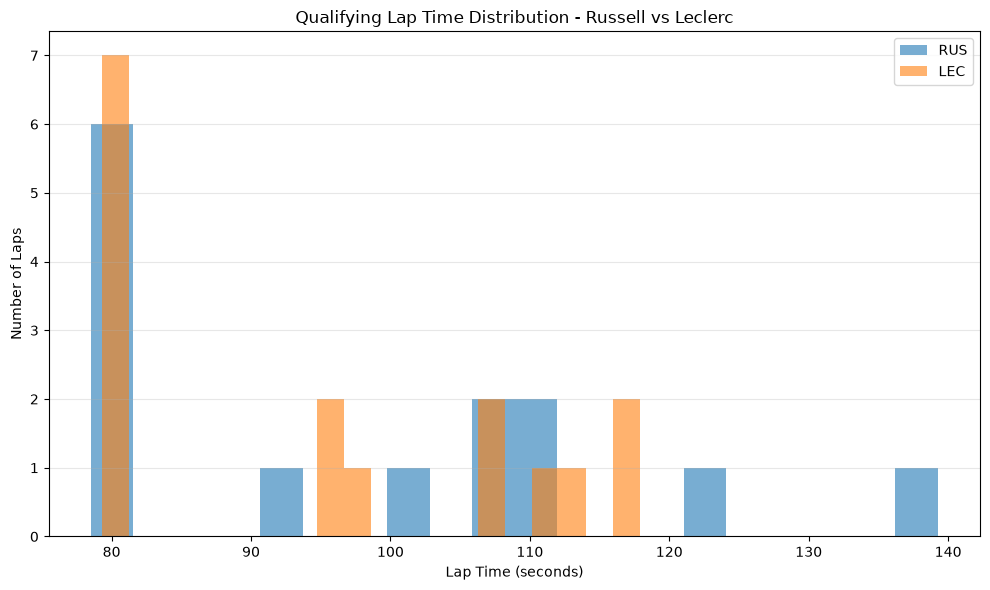

In [16]:
# ============================================================
# LAP TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

for driver in ["RUS", "LEC"]:

    data = valid_laps[
        valid_laps["Driver"] == driver
    ]

    plt.hist(
        data["LapTimeSeconds"],
        bins=20,
        alpha=0.6,
        label=driver
    )

plt.xlabel("Lap Time (seconds)")
plt.ylabel("Number of Laps")

plt.title(
    "Qualifying Lap Time Distribution - Russell vs Leclerc"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lap_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

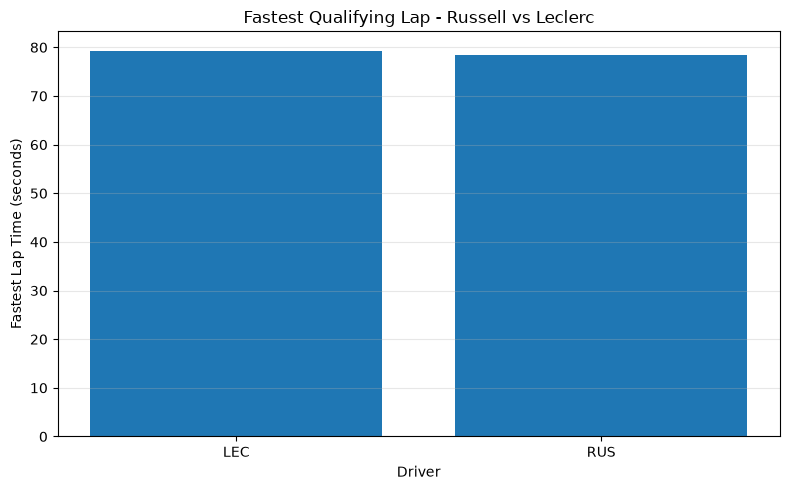

In [17]:
# ============================================================
# FASTEST LAP COMPARISON
# ============================================================

comparison = driver_summary.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Driver"],
    comparison["BestLap"]
)

plt.ylabel("Fastest Lap Time (seconds)")

plt.xlabel("Driver")

plt.title(
    "Fastest Qualifying Lap - Russell vs Leclerc"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/fastest_lap_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()